# Missing Hospital Appointments
By Jessica Hislop, Jasper Cordero and Momina Amin

# Business problem: 
Why are patients missing appointments, and how can hospitals reduce no show appoinments?

## Why is this problem important?
Missing hospital appointments have a significant impact on the quality of healthcare services. They can lead to inefficient resource allocation, lost revenue, and increased waiting times for other patients. Furthermore, missing appointments may delay diagnosis and treatment plans which can negatively affect patient outcomes. Therefore, it is important for hospitals to understand the reasons why patients fail to attend their appointments, and to develop strategies that will reduce no-show rates and improve overall patient care.

# Dataset:
The dataset we chose is a hospital appointment no-show prediction dataset.

## Why we chose this dataset:
The Hospital appointment prediction dataset from Kaggle is suitable for our project because it directly aligns with our core  business problem of predicting which patients are likely to miss their appointments.The dataset includes a wide range of demographics and appointment related variables making it more inclusive and comprehensive for analysis.  Since  the target variable is binary , it makes it easier and suitable to use classification models such as regression , decision trees etc…Furthermore, this is a synthetic dataset which means that it does not include real patient records or personal information. This ensures that the data chosen complies with GDPR regulations and keeps data protected. The dataset also provides for exploratory  data analysis and machine learning, allowing us to identify key patterns and risk factors why many people missed appointments. Overall , it enables us to develop a predictive model that can help healthcare providers improve resource allocation , reduce wasted appointment slots and enhance operational efficiency within healthcare services. 


# Understanding the dataset

This section will be use understanding the no-show appointment dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("hospital_appointment_no_show_5000 3.csv")
df.head()
#Preview of the dataset to check it has loaded correctly

,patient_id,age,gender,city_type,distance_km,travel_time_min,appointment_day,appointment_time_slot,department,waiting_days,...,chronic_disease,sms_reminder,email_reminder,num_reminders,employment_status,education_level,insurance_status,rainy_day,public_holiday,no_show
0,1,47.0,Female,Suburban,16.5,77.3,Sat,Evening,Pediatrics,8,...,0,1,0.0,1,NaN,Higher,Uninsured,1,0,1
1,2,37.0,Male,Suburban,6.7,26.9,Tue,Morning,Cardiology,8,...,1,1,0.0,2,Employed,Secondary,Insured,0,1,0
2,3,49.0,Female,Rural,8.2,46.1,Sat,Evening,General Medicine,3,...,0,1,0.0,1,Unemployed,Secondary,Insured,0,0,1
3,4,62.0,Female,Urban,2.6,15.2,Thu,Evening,General Medicine,12,...,1,0,1.0,1,NaN,Secondary,Insured,0,0,0
4,5,36.0,Female,Suburban,4.1,13.8,Fri,Morning,Dermatology,8,...,0,1,0.0,1,NaN,Secondary,Insured,0,0,1


In [2]:
df.shape
#Total rows and columns

(5000, 24)

In [3]:
df.info()
#Shows which columns are numeric, categorical and if there are missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   patient_id             5000 non-null   int64  
 1   age                    4610 non-null   float64
 2   gender                 5000 non-null   object 
 3   city_type              5000 non-null   object 
 4   distance_km            4612 non-null   float64
 5   travel_time_min        4584 non-null   float64
 6   appointment_day        5000 non-null   object 
 7   appointment_time_slot  5000 non-null   object 
 8   department             5000 non-null   object 
 9   waiting_days           5000 non-null   int64  
 10  previous_appointments  5000 non-null   int64  
 11  previous_no_shows      5000 non-null   int64  
 12  diabetes               5000 non-null   int64  
 13  hypertension           5000 non-null   int64  
 14  chronic_disease        5000 non-null   int64  
 15  sms_

Columns that have missing values: age, distance_km, travel_time_min, email_reminder, employment_status, education_level

In [4]:
missing = df.isnull().sum()
missing[missing > 0]
# How much is missing from each category

age                  390
distance_km          388
travel_time_min      416
email_reminder       440
employment_status    388
education_level      391
dtype: int64

In [5]:
missing_percent = (df.isnull().mean() * 100).sort_values(ascending=False)
missing_percent[missing_percent > 0]
# Percentage output of missing values

email_reminder       8.80
travel_time_min      8.32
education_level      7.82
age                  7.80
distance_km          7.76
employment_status    7.76
dtype: float64

The missing values do not exceed 10%, it makes more sense to impute instead of delete data.

In [6]:
df["no_show"].value_counts()
df["no_show"].value_counts(normalize=True)

no_show
1    0.5
0    0.5
Name: proportion, dtype: float64

Data is perfectly balanced 50/50.

In [7]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

print("Numeric:", num_cols)
print("Categorical:", cat_cols)

Numeric: Index(['patient_id', 'age', 'distance_km', 'travel_time_min', 'waiting_days',
       'previous_appointments', 'previous_no_shows', 'diabetes',
       'hypertension', 'chronic_disease', 'sms_reminder', 'email_reminder',
       'num_reminders', 'rainy_day', 'public_holiday', 'no_show'],
      dtype='object')
Categorical: Index(['gender', 'city_type', 'appointment_day', 'appointment_time_slot',
       'department', 'employment_status', 'education_level',
       'insurance_status'],
      dtype='object')


The dataset variables were sperated into groups (numeric or categorical) based on their data types. This will help ensure the data set is analysed and visualised with the appropriate methods.

In [8]:
df.describe()

,patient_id,age,distance_km,travel_time_min,waiting_days,previous_appointments,previous_no_shows,diabetes,hypertension,chronic_disease,sms_reminder,email_reminder,num_reminders,rainy_day,public_holiday,no_show
count,5000.000000,4610.000000,4612.000000,4584.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,4560.000000,5000.000000,5000.000000,5000.000000,5000.00000
mean,2500.500000,39.643167,8.310169,41.967779,6.990600,2.005600,0.40180,0.186200,0.287200,0.476400,0.706800,0.401535,1.404200,0.207000,0.099800,0.50000
std,1443.520003,14.925693,4.604878,23.271754,2.671917,1.423227,0.64687,0.389307,0.452501,0.499493,0.455275,0.490263,0.814466,0.405196,0.299763,0.50005
min,1.000000,0.000000,0.000000,5.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,1250.750000,30.000000,4.800000,23.600000,5.000000,1.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.00000
50%,2500.500000,40.000000,8.100000,40.700000,7.000000,2.000000,0.00000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.50000
75%,3750.250000,49.750000,11.400000,57.525000,9.000000,3.000000,1.00000,0.000000,1.000000,1.000000,1.000000,1.000000,2.000000,0.000000,0.000000,1.00000
max,5000.000000,90.000000,30.400000,128.400000,21.000000,9.000000,5.00000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000,1.000000,1.00000


This table shows a statistical summary of the numerical variables. It provides an overview of the central tendency and distribution. This table allows us to give a quick check for possible outliers, missing data and errors.

# Cleaning the data

## Handling missing values

The dataset contains missing values in the age, distance_km, travel_time_min, education_level, and employment_status columns. The missing values are under 10% which is relatively small suggesting that the missing data is random. Instead of removing rows and reducing the dataset, we used imputation techniques to preserve the available data.

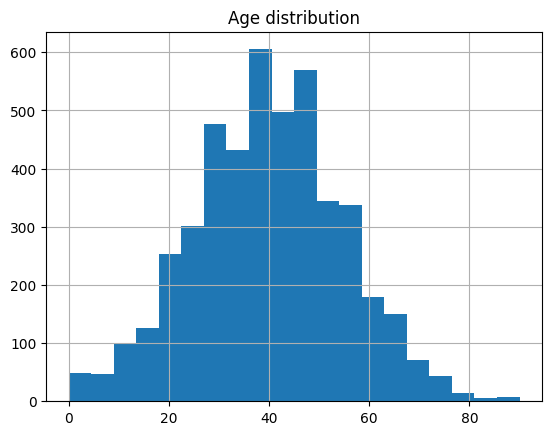

In [9]:
df["age"].hist(bins=20)
plt.title("Age distribution")
plt.show()

In [10]:
median_age = df["age"].median()
df["age"] = df["age"].fillna(median_age)

In [11]:
df["age"].isnull().sum()

np.int64(0)

To handle missing values in the age category we used a histogram to analyse the distribution. It shows a slightly skewed distribution, with majority between 25 and 50 years. Due to this skewed distribution, we used median imputation instead of the mean as it is less likely to be effected by outliers. After filling out the values with the median age, we checked to confirm there were no missing values in the age column. 

In [12]:
median_distance = df["distance_km"].median()
df["distance_km"] = df["distance_km"].fillna(median_distance)

In [13]:
df["distance_km"].isnull().sum()

np.int64(0)

In [14]:
median_travel = df["travel_time_min"].median()
df["travel_time_min"] = df["travel_time_min"].fillna(median_travel)

In [15]:
df["travel_time_min"].isnull().sum()

np.int64(0)

Median imputation was also used to handle the missing values in the numerical variables distance_km and travel_time_min. This was chosen as the median is less sensitive to extrea, values and provides a reliable measure of central tendency. After a check was used to confirm there are no missing values in these columns. 

In [16]:
mode_email = df["email_reminder"].mode()[0]
df["email_reminder"] = df["email_reminder"].fillna(mode_email)

In [17]:
df["email_reminder"].isnull().sum()

np.int64(0)

In [18]:
mode_employment = df["employment_status"].mode()[0]
df["employment_status"] = df["employment_status"].fillna(mode_employment)

In [19]:
df["employment_status"].isnull().sum()

np.int64(0)

In [20]:
mode_education = df["education_level"].mode()[0]
df["education_level"] = df["education_level"].fillna(mode_education)

In [21]:
df["education_level"].isnull().sum()

np.int64(0)

For the email_reminder, employment_status, and education_level missing data mode imputation was used. This method was chosen as the columns are categorical therefore mean or median cannot be used. The mode method is most commonly used to replace values without disorting the dataset. A check was used after impution to verfiy there are no missing values left in these columns. 

In [22]:
df.isnull().sum()

patient_id               0
age                      0
gender                   0
city_type                0
distance_km              0
travel_time_min          0
appointment_day          0
appointment_time_slot    0
department               0
waiting_days             0
previous_appointments    0
previous_no_shows        0
diabetes                 0
hypertension             0
chronic_disease          0
sms_reminder             0
email_reminder           0
num_reminders            0
employment_status        0
education_level          0
insurance_status         0
rainy_day                0
public_holiday           0
no_show                  0
dtype: int64

A final check to ensure there are no missing values remaining in the dataset.

## Duplicate rows

In [23]:
df.duplicated().sum()

np.int64(0)

There are no duplicated rows in the dataset.

## Data types

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   patient_id             5000 non-null   int64  
 1   age                    5000 non-null   float64
 2   gender                 5000 non-null   object 
 3   city_type              5000 non-null   object 
 4   distance_km            5000 non-null   float64
 5   travel_time_min        5000 non-null   float64
 6   appointment_day        5000 non-null   object 
 7   appointment_time_slot  5000 non-null   object 
 8   department             5000 non-null   object 
 9   waiting_days           5000 non-null   int64  
 10  previous_appointments  5000 non-null   int64  
 11  previous_no_shows      5000 non-null   int64  
 12  diabetes               5000 non-null   int64  
 13  hypertension           5000 non-null   int64  
 14  chronic_disease        5000 non-null   int64  
 15  sms_

This table shows us the different data types for each variable, we can analyse to see if the data types are appropriate for that variable. Where another type would fit better we will change it. 

In [25]:
df["email_reminder"] = df["email_reminder"].astype(int)

The email_reminder variable makes more sense being integer instead of float.

In [26]:
categorical_cols = [
    "gender", "city_type", "appointment_day", 
    "appointment_time_slot", "department", 
    "employment_status", "education_level",
    "insurance_status"
]
for col in categorical_cols:
    df[col] = df[col].astype("category")

These variables have been converted to category data type to better represent categorical information and increase analysis efficiency later on.

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   patient_id             5000 non-null   int64   
 1   age                    5000 non-null   float64 
 2   gender                 5000 non-null   category
 3   city_type              5000 non-null   category
 4   distance_km            5000 non-null   float64 
 5   travel_time_min        5000 non-null   float64 
 6   appointment_day        5000 non-null   category
 7   appointment_time_slot  5000 non-null   category
 8   department             5000 non-null   category
 9   waiting_days           5000 non-null   int64   
 10  previous_appointments  5000 non-null   int64   
 11  previous_no_shows      5000 non-null   int64   
 12  diabetes               5000 non-null   int64   
 13  hypertension           5000 non-null   int64   
 14  chronic_disease        5000 non-null   i

This table provides the variables with their new data types.

## Value range checks

In [28]:
df["age"].describe()

count    5000.000000
mean       39.671000
std        14.331973
min         0.000000
25%        31.000000
50%        40.000000
75%        49.000000
max        90.000000
Name: age, dtype: float64

In [29]:
df[df["distance_km"] < 0]
df[df["travel_time_min"] < 0]
df[df["waiting_days"] < 0]

,patient_id,age,gender,city_type,distance_km,travel_time_min,appointment_day,appointment_time_slot,department,waiting_days,...,chronic_disease,sms_reminder,email_reminder,num_reminders,employment_status,education_level,insurance_status,rainy_day,public_holiday,no_show


The numerical variables were reviewed to ensure the dataset is realistc, such as no negative numbers in age or extreamly high travel times.

## Binary variables check

In [30]:
binary_cols = [
    "diabetes", "hypertension", "chronic_disease",
    "sms_reminder", "email_reminder",
    "rainy_day", "public_holiday", "no_show"
]
for col in binary_cols:
    print(col, df[col].unique())

diabetes [0 1]
hypertension [0 1]
chronic_disease [0 1]
sms_reminder [1 0]
email_reminder [0 1]
rainy_day [1 0]
public_holiday [0 1]
no_show [1 0]


Binary variables were checked to ensure they contained only vaild binary values (0 and 1), the output confirmed their values and no further cleaning is required.

## Categorical values check

In [31]:
categorical_cols = [
    "gender", "city_type", "appointment_day",
    "appointment_time_slot", "department", 
    "employment_status", "education_level", "insurance_status"
]
for col in categorical_cols:
    print(col, df[col].astype(str).unique())

gender ['Female' 'Male']
city_type ['Suburban' 'Rural' 'Urban']
appointment_day ['Sat' 'Tue' 'Thu' 'Fri' 'Wed' 'Mon']
appointment_time_slot ['Evening' 'Morning' 'Afternoon']
department ['Pediatrics' 'Cardiology' 'General Medicine' 'Dermatology' 'Orthopedics']
employment_status ['Employed' 'Unemployed' 'Student']
education_level ['Higher' 'Secondary' 'Primary']
insurance_status ['Uninsured' 'Insured']


The categorical variables were checked to confirm they are consistent and formatted correctly. The output shows that there are no irregular values.

## Checking for outliers

In [32]:
df[["age","distance_km","travel_time_min","waiting_days"]].describe()

,age,distance_km,travel_time_min,waiting_days
count,5000.000000,5000.000000,5000.000000,5000.000000
mean,39.671000,8.293860,41.862300,6.990600
std,14.331973,4.422922,22.285178,2.671917
min,0.000000,0.000000,5.000000,0.000000
25%,31.000000,5.100000,25.300000,5.000000
50%,40.000000,8.100000,40.700000,7.000000
75%,49.000000,11.100000,55.600000,9.000000
max,90.000000,30.400000,128.400000,21.000000


This numerical statistical summary table was used to help identify outliers in the dataset. All the variables fall in reasonable ranges for their variables, meaning there are no extreme outliers and no futher cleaning was required.

In [34]:
df.to_csv("cleaned_hospital_dataset.csv", index=False)

This code saves the new cleaned dataset to the folder to allow for visualisations and further analysis.

# Visualisations

In [36]:
import pandas as pd
df = pd.read_csv("cleaned_hospital_dataset.csv")